In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import scipy
import numpy as np
import pandas as pd

In [9]:
from data_load import scaled_data, raw_data, result, data_info

In [10]:
scaled_data['입열량'] = scaled_data['전류'] * scaled_data['전압'] * scaled_data['통전시간']
scaled_data.head()

,Unnamed: 0,용접 가압력,전류,전압,통전시간,입열량
0,0,0.004482,0.001717,0.002506,0.000461,1.982633e-09
1,1,0.005412,0.000501,0.002506,0.000922,1.156537e-09
2,2,0.004989,0.000358,0.507830,0.000922,1.674226e-07
3,3,0.005243,0.000358,0.002506,0.000922,8.260981e-10
4,4,0.005327,0.000143,0.002506,0.000461,1.652194e-10


In [11]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [12]:
# Thickness는 모두 같은 값이므로 예측에 영향 X

print(np.sum(raw_data['Thickness 1(mm)'] != 0.7))
print(np.sum(raw_data['Thickness 2(mm)'] != 0.7))

0
0


In [13]:
scaled_data = scaled_data.drop(columns = ['Unnamed: 0'])

In [14]:
# Generalized ESD 기반 다변량 이상치 탐지
from scipy.stats import t

# 각 행을 하나의 관측치로 보고 Mahalanobis 거리 제곱을 이상치 점수로 사용
feature_values = scaled_data.to_numpy(dtype=float)
feature_values[~np.isfinite(feature_values)] = np.nan
feature_medians = np.nanmedian(feature_values, axis=0)
feature_medians = np.nan_to_num(feature_medians, nan=0.0)
missing_values = np.isnan(feature_values)
feature_values[missing_values] = np.take(
    feature_medians,
    np.where(missing_values)[1],
)

feature_center = feature_values.mean(axis=0)
feature_covariance = np.cov(feature_values, rowvar=False)
feature_covariance = np.nan_to_num(feature_covariance)
feature_covariance_inverse = np.linalg.pinv(feature_covariance, hermitian=True)
centered_values = feature_values - feature_center
anomaly_scores = np.einsum(
    'ij,jk,ik->i',
    centered_values,
    feature_covariance_inverse,
    centered_values,
)

# ESD가 검사할 수 있는 최대 이상치 수
max_outliers = max(1, int(np.ceil(0.0038 * len(anomaly_scores))))
esd_alpha = 0.05
remaining_indices = np.arange(len(anomaly_scores))
removed_indices = []
test_statistics = []
critical_values = []

for step in range(1, max_outliers + 1):
    remaining_scores = anomaly_scores[remaining_indices]
    score_mean = remaining_scores.mean()
    score_std = remaining_scores.std(ddof=1)

    if score_std == 0 or len(remaining_scores) < 3:
        break

    distances_from_mean = np.abs(remaining_scores - score_mean) / score_std
    largest_position = np.argmax(distances_from_mean)
    test_statistics.append(distances_from_mean[largest_position])
    removed_indices.append(remaining_indices[largest_position])

    sample_count = len(remaining_scores)
    degrees_of_freedom = sample_count - step - 1
    significance = 1 - esd_alpha / (sample_count - step + 1)
    critical_t = t.ppf(significance, degrees_of_freedom)
    critical_value = (
        (sample_count - step) * critical_t
        / np.sqrt(
            (sample_count - step - 1 + critical_t ** 2)
            * (sample_count - step + 1)
        )
    )
    critical_values.append(critical_value)
    remaining_indices = np.delete(remaining_indices, largest_position)

# R_i > lambda_i인 마지막 단계까지를 이상치로 확정
significant_steps = [
    step for step, (test_statistic, critical_value)
    in enumerate(zip(test_statistics, critical_values), start=1)
    if test_statistic > critical_value
]

if significant_steps:
    anomaly_count = max(significant_steps)
    anomaly_indices = np.asarray(removed_indices[:anomaly_count], dtype=int)
else:
    anomaly_indices = np.array([], dtype=int)

predictions = np.ones(len(scaled_data), dtype=int)
predictions[anomaly_indices] = -1

print(f'ESD로 탐지된 이상치 수: {len(anomaly_indices)}')


ESD로 탐지된 이상치 수: 46


In [25]:
print(np.sort(anomaly_indices))

[   26    47    55    94   426   427  1693  1943  1944  2108  2472  2527
  3595  4757  4758  4806  4922  5192  5193  5239  5402  6594  6669  7118
  7119  7620  7621  7930  8141  8271  8284  9594 10313 10725 10726 10920
 11003 11268 11269 11303 11319 11699 11700 11875 11921 11922]


In [ ]:
# 이상치 군집화

idx = (predictions == -1)

X = scaled_data.loc[idx, :].copy() 

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

In [16]:
X['cluster'] = labels

X.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
26,0.005412,0.000429,0.608060,0.000461,1.202798e-07,0
47,1.000000,0.000572,0.002610,0.000922,1.376830e-09,2
55,0.940808,0.000501,0.002506,0.000922,1.156537e-09,2
94,0.005158,0.532837,0.002610,0.000922,1.281829e-06,2
426,0.005158,0.001073,0.002506,0.705991,1.898373e-06,1


In [ ]:
undercut_idx = result['defect type'] == 1
lack_idx = result['defect type'] == 2
crack_idx = result['defect type'] == 3


anomaly1 = np.sum(labels == 0) 
anomaly2 = np.sum(labels == 1) 
anomaly3 = np.sum(labels == 2) 
print(anomaly1, anomaly2, anomaly3)
print()

defect = pd.Series(result['defect'], dtype=int)
print(np.sum(defect[undercut_idx]),np.sum(defect[crack_idx]), np.sum(defect[lack_idx]))

14 12 20

14 12 13


In [18]:
anomaly1 = X.loc[X['cluster'] == 0, :]
anomaly2 = X.loc[X['cluster'] == 1, :]
anomaly3 = X.loc[X['cluster'] == 2, :]

In [ ]:
anomaly1.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
26,0.005412,0.000429,0.608060,0.000461,1.202798e-07,0
1943,0.043210,0.003076,0.686782,0.000922,1.947210e-06,0
1944,0.043210,0.003076,0.791188,0.000922,2.243228e-06,0
4757,0.043210,0.003076,0.791188,0.000922,2.243228e-06,0
4758,0.043210,0.003076,0.895594,0.000922,2.539247e-06,0
5192,0.005327,0.000501,0.647734,0.000922,2.989649e-07,0
5193,0.005327,0.000501,0.752140,0.000461,1.735768e-07,0
5239,0.005327,0.000501,0.647734,0.000461,1.494823e-07,0
9594,0.005243,0.001574,0.561077,0.000461,4.069493e-07,0
10725,0.004566,0.003362,0.968261,0.000461,1.500324e-06,0


In [20]:
anomaly2.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
426,0.005158,0.001073,0.002506,0.705991,0.000002,1
427,0.005158,0.001073,0.002506,0.705991,0.000002,1
2108,0.052173,0.003219,0.003132,0.945622,0.000010,1
2472,0.005158,0.001073,0.002506,0.705991,0.000002,1
2527,0.005243,0.001574,0.002506,1.000000,0.000004,1


In [21]:
anomaly3.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
47,1.000000,0.000572,0.002610,0.000922,1.376830e-09,2
55,0.940808,0.000501,0.002506,0.000922,1.156537e-09,2
94,0.005158,0.532837,0.002610,0.000922,1.281829e-06,2
1693,0.004989,0.512448,0.002610,0.000922,1.232779e-06,2
3595,0.004989,0.486336,0.002506,0.000922,1.123163e-06,2


C:\Users\82105\AppData\Local\Temp\ipykernel_8684\2879493542.py:39: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_8684\2879493542.py:39: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_8684\2879493542.py:39: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_8684\2879493542.py:39: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_8684\2879493542.py:39: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_8684\2879493542.py:39: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from f

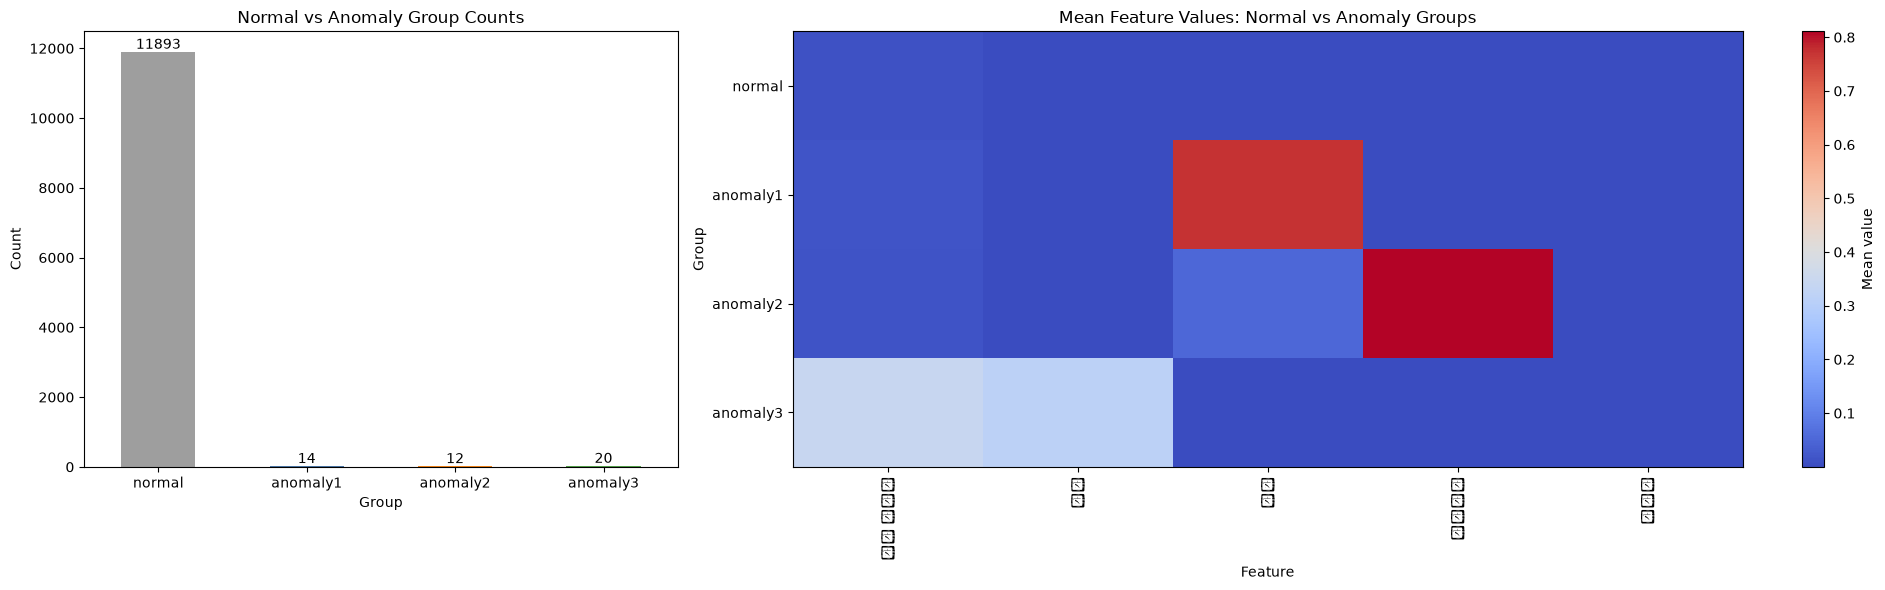

,normal,anomaly1,anomaly2,anomaly3
용접 가압력,0.010,0.019,0.013,0.343
전류,0.002,0.002,0.001,0.315
전압,0.003,0.770,0.054,0.003
통전시간,0.002,0.001,0.811,0.001
입열량,0.000,0.000,0.000,0.000


In [22]:
# Isolation Forest에서 정상으로 판정된 데이터
normal_data = scaled_data.loc[predictions == 1, :]

comparison_groups = {
    'normal': normal_data,
    'anomaly1': anomaly1,
    'anomaly2': anomaly2,
    'anomaly3': anomaly3,
}

# 정상 데이터와 anomaly 그룹별 데이터 개수 비교
counts = pd.Series({name: len(group) for name, group in comparison_groups.items()})

fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 2]})

counts.plot(kind='bar', ax=axes[0], color=['#9E9E9E', '#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Normal vs Anomaly Group Counts')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for index, value in enumerate(counts):
    axes[0].text(index, value, str(value), ha='center', va='bottom')

# 정상 데이터와 anomaly 그룹의 변수별 평균값 비교
mean_values = pd.DataFrame({name: group.drop(columns='cluster', errors='ignore').mean()
                            for name, group in comparison_groups.items()})
mean_values = mean_values.select_dtypes(include='number')

image = axes[1].imshow(mean_values.T, aspect='auto', cmap='coolwarm')
axes[1].set_title('Mean Feature Values: Normal vs Anomaly Groups')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Group')
axes[1].set_xticks(range(len(mean_values.index)))
axes[1].set_xticklabels(mean_values.index, rotation=90)
axes[1].set_yticks(range(len(mean_values.columns)))
axes[1].set_yticklabels(mean_values.columns)
fig.colorbar(image, ax=axes[1], label='Mean value')

plt.tight_layout()
plt.show()

mean_values.round(3)
